In [202]:
import numpy as np
import struct
import matplotlib.pyplot as plt

In [203]:
train_labels_fpath = "mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte"
train_images_fpath = "mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte"
test_labels_fpath = "mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte"
test_images_fpath = "mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte"
np.random.seed(2023115)

In [204]:

def sample_data(images, labels, sample_size=100):
    cats=[]
    for l in labels:
        if (l not in cats):
            cats.append(l)
    final_imgs=[]
    final_tags=[]
    for c in cats:
        idxs=[]
        for i in range(len(labels)):
            if(labels[i]==c):
                idxs.append(i)
        chosen_idx = np.random.choice(idxs, sample_size, replace=False)
        for idx in chosen_idx:
            final_imgs.append(images[idx])
            final_tags.append(labels[idx])
    X = np.array(final_imgs)
    y = np.array(final_tags)
    p = np.random.permutation(len(y))
    X = X[p]
    y = y[p]
    
    return X, y

In [205]:
def load_dataset(image_file, label_file):
    with open(label_file, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    with open(image_file, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images, labels
    

In [206]:
def filter012(images, labels):
    classes=(0, 1, 2)
    indices = np.where((labels == classes[0]) | (labels == classes[1]) | (labels == classes[2]))[0]
    return images[indices], labels[indices]

In [207]:
def preprocess(images):
    max_pixel_value = 255.0
    samples_cnt = images.shape[0]
    flatten_images = images.reshape(samples_cnt, -1)
    norm_images = flatten_images / max_pixel_value
    return norm_images

In [ ]:
def principalComponent(train_images, var, comp=None):
    data_mu = np.mean(train_images, axis=1, keepdims=True)
    corrected_data_matrix = train_images - data_mu
    cov_S = np.dot(corrected_data_matrix, corrected_data_matrix.T) / 299
    eigVals, vec = np.linalg.eigh(cov_S)
    sorted_idx = np.argsort(eigVals)[::-1]
    eigVals = eigVals[sorted_idx]
    vec = vec[:, sorted_idx]

    if comp is not None:
        k = comp
    elif var is not None:
        total_var = np.sum(eigVals)
        var_sum = 0
        k = 0
        for i in range(len(eigVals)):
            var_sum += eigVals[i]
            if (var_sum / total_var) >= var:
                k = i + 1 
                break
    else:
        k = train_images.shape[0]
    Up = vec[:, :k]
    Y = np.dot(Up.T, corrected_data_matrix)
    return Y, Up, eigVals[:k]


In [ ]:
def fischerDA(train_images, train_labels):
    feat_cnt = train_images.shape[0]
    cats = np.unique(train_labels)
    mu_glob = np.mean(train_images, axis=1, keepdims=True)
    S_w = np.zeros((feat_cnt, feat_cnt))
    S_bw = np.zeros((feat_cnt, feat_cnt))
    for c in cats:
        samples = train_images[:, train_labels == c]
        mu_c = np.mean(samples, axis=1, keepdims=True)
        centered = samples - mu_c
        S_w += (centered @ centered.T)
        mu_diff = mu_c - mu_glob
        n_c = samples.shape[1]
        S_bw += n_c * (mu_diff @ mu_diff.T)
    S_w += np.eye(feat_cnt) * 1e-6 
    mat = np.linalg.pinv(S_w) @ S_bw
    
    eigVals, vec = np.linalg.eig(mat)
    idx_desc = np.argsort(np.real(eigVals))[::-1]
    top_idx = idx_desc[:len(cats) - 1]
    W = np.real(vec[:, top_idx])
    return W

In [210]:
def accuracy(pred, labels):
    num_sample = len(pred)
    correct = np.sum(pred == labels)
    return (correct / num_sample)*100

def project_pca(data, Up, mean):
    return Up.T @ (data.T - mean)

def project_test_pca(X_test_t, Up, train_mean):
    centered_test = X_test_t - train_mean
    return np.dot(Up.T, centered_test)

In [211]:
def MLEstimate(train_images, train_labels):
    reg = 1e-5
    classes = np.unique(train_labels)
    params={}
    for c in classes:
        class_images = train_images[train_labels == c]
        N = class_images.shape[0]
        mean = np.mean(class_images, axis=0)        ## u
        centered_images = class_images - mean ## (x-u)
        covmat = np.dot(centered_images.T, centered_images) / N  ## 1/N (x-u)^t (x-u)
        covmat += reg * np.eye(covmat.shape[0]) ## Regularization
        prior = N / len(train_labels) ## P(y=c) = N_c/N
        params[c] = (mean, covmat, prior)
    return params


In [212]:
def LDA(test_images, test_labels, params, dataset_name="Test"):
    categories = list(params.keys())
    cov_pooled = np.zeros_like(params[categories[0]][1])
    for c in categories:
        cov_pooled += params[c][1]
    cov_pooled /= len(categories)

    try:
        cov_inv = np.linalg.inv(cov_pooled)
    except np.linalg.LinAlgError: 
        cov_inv = np.linalg.pinv(cov_pooled)
    pred_labels = []
    first_scores = None
    for i, x in enumerate(test_images):
        scores = []
        for c in categories:
            mean = params[c][0]
            prior = params[c][2]
            score = -0.5 * np.dot(np.dot((x - mean).T, cov_inv), (x - mean)) + np.log(prior)
            scores.append(score)
        if i == 0:
            first_scores = scores
        pred_labels.append(categories[np.argmax(scores)])

    pred_labels = np.array(pred_labels)
    acc = np.mean(pred_labels == test_labels) * 100
    print(f"LDA Discriminant values for first {dataset_name.lower()} sample:", 
          [f"Class {c}: {s:.2f}" for c, s in zip(categories, first_scores)])
    print(f"LDA {dataset_name} Accuracy: {acc:.2f}%")
    return pred_labels, acc


In [ ]:
def QDA(test_images, test_labels, params, dataset_name="Test"):
    labels = list(params.keys())
    pred_labels = []
    cat_params = {}
    
    for idx in labels:
        covmat = params[idx][1]
        try:
            sign, logdet = np.linalg.slogdet(covmat)
            if (sign <= 0):
                print(f"Covariance matrix for class {idx} is not positive definite.")
            cov_inv = np.linalg.inv(covmat)
        except np.linalg.LinAlgError: 
            cov_inv = np.linalg.pinv(covmat)
            logdet = 0
        cat_params[idx] = (cov_inv, logdet)
    first_scores = None
    
    for i, x in enumerate(test_images):
        scores = []
        for c in labels:
            mu = params[c][0]
            prior = params[c][2]
            cov_inv, logdet = cat_params[c]
            score = -0.5 * np.dot(np.dot((x - mu).T, cov_inv), (x - mu)) - 0.5 * logdet + np.log(prior)
            scores.append(score)
        if i == 0:
            first_scores = scores
        pred_labels.append(labels[np.argmax(scores)])

    pred_labels = np.array(pred_labels)
    acc = np.mean(pred_labels == test_labels) * 100
    print(f"QDA Discriminant values for first {dataset_name.lower()} sample:", 
          [f"Class {c}: {s:.2f}" for c, s in zip(labels, first_scores)])
    print(f"QDA {dataset_name} Accuracy: {acc:.2f}%")
    return pred_labels, acc


In [214]:

train_imgs_raw, train_labels_raw = load_dataset(train_images_fpath, train_labels_fpath)
test_imgs_raw, test_labels_raw = load_dataset(test_images_fpath, test_labels_fpath)
train_imgs_012, train_labels_012 = filter012(train_imgs_raw, train_labels_raw)
test_imgs_012, test_labels_012 = filter012(test_imgs_raw, test_labels_raw)

# Randomly sample 100 from each class
X_train, y_train = sample_data(train_imgs_012, train_labels_012)
X_test, y_test = sample_data(test_imgs_012, test_labels_012)
X_train_norm = preprocess(X_train)
X_test_norm = preprocess(X_test)
X_train_t = X_train_norm.T 
X_test_t = X_test_norm.T

print("Train shape (features, samples):", X_train_t.shape)
print("Test shape (features, samples):", X_test_t.shape)

Train shape (features, samples): (784, 300)
Test shape (features, samples): (784, 300)


Components used for 75% variance: 20


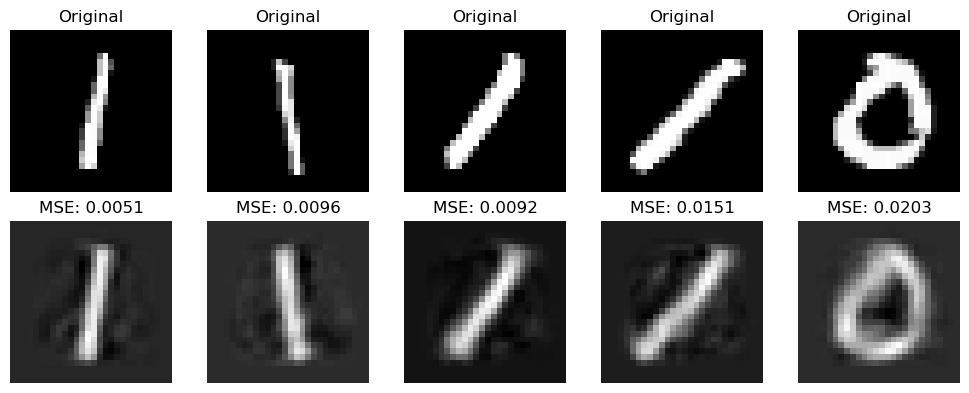

In [215]:
# 1. Project and Reconstruct
Y_t_75, Up_75, _ = principalComponent(X_train_t, var=0.75)
mean_train = np.mean(X_train_t, axis=1, keepdims=True)
X_recon = (Up_75 @ Y_t_75) + mean_train

print(f"Components used for 75% variance: {Y_t_75.shape[0]}")
plt.figure(figsize=(10, 4))
for i in range(5):
    mse = np.mean((X_train_t[:, i] - X_recon[:, i])**2)
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_t[:, i].reshape(28,28), cmap='gray'), plt.axis('off')
    plt.title("Original")
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_recon[:, i].reshape(28,28), cmap='gray'), plt.axis('off')
    plt.title(f"MSE: {mse:.4f}")
plt.tight_layout()
plt.show()

In [216]:
# Apply FDA and evaluate with LDA/QDA
fda_vec = fischerDA(X_train_t, y_train)
X_train_fda = np.dot(X_train_norm, fda_vec) 
X_test_fda = np.dot(X_test_norm, fda_vec)
params_fda = MLEstimate(X_train_fda, y_train)


print("FDA with LDA")

LDA(X_train_fda, y_train, params_fda, dataset_name="Train")
print()
LDA(X_test_fda, y_test, params_fda, dataset_name="Test")

print()

print("FDA with QDA")

QDA(X_train_fda, y_train, params_fda, dataset_name="Train")
print()
QDA(X_test_fda, y_test, params_fda, dataset_name="Test")


FDA with LDA
LDA Discriminant values for first train sample: ['Class 0: -14767.48', 'Class 1: -1.10', 'Class 2: -7169.47']
LDA Train Accuracy: 100.00%

LDA Discriminant values for first test sample: ['Class 0: -1658.48', 'Class 1: -11441.19', 'Class 2: -13850.67']
LDA Test Accuracy: 86.67%

FDA with QDA
QDA Discriminant values for first train sample: ['Class 0: -14755.96', 'Class 1: 10.41', 'Class 2: -7157.96']
QDA Train Accuracy: 100.00%

QDA Discriminant values for first test sample: ['Class 0: -1646.97', 'Class 1: -11429.68', 'Class 2: -13839.15']
QDA Test Accuracy: 86.67%


(array([0, 1, 0, 2, 1, 1, 2, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 1, 1, 2, 2, 0,
        1, 0, 2, 0, 2, 0, 1, 0, 1, 0, 2, 2, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2,
        2, 2, 1, 1, 2, 2, 2, 0, 0, 2, 1, 1, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0,
        1, 1, 2, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
        1, 2, 1, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2,
        1, 2, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 0, 2, 2, 2, 1, 0, 1, 1, 2,
        1, 1, 1, 1, 1, 0, 2, 1, 2, 2, 1, 1, 0, 2, 1, 0, 0, 2, 0, 2, 2, 2,
        0, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 1, 2, 2, 0, 1, 1, 1, 0, 2, 0, 0,
        0, 2, 2, 1, 0, 2, 1, 1, 0, 2, 1, 1, 1, 1, 0, 1, 1, 2, 0, 2, 2, 1,
        1, 1, 1, 2, 0, 1, 1, 2, 0, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 0, 0, 1,
        0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 2, 1, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0,
        1, 2, 1, 0, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 1,
        2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 2, 2, 2, 1, 1, 0, 2, 2, 1, 2, 2, 1,
        0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 

In [ ]:

print("PCA 75% Variance + LDA")
Y_test_75 = project_test_pca(X_test_t, Up_75, mean_train)
p_var75 = MLEstimate(Y_t_75.T, y_train)
LDA(Y_t_75.T, y_train, p_var75, dataset_name="Train")
print()
LDA(Y_test_75.T, y_test, p_var75, dataset_name="Test")

print()

print("PCA 90% Variance + LDA")
Y_train_90, Up_90, _ = principalComponent(X_train_t, var=0.90, comp=None)
Y_test_90 = project_test_pca(X_test_t, Up_90, mean_train)
p_var90 = MLEstimate(Y_train_90.T, y_train)
LDA(Y_train_90.T, y_train, p_var90, dataset_name="Train")
print()
LDA(Y_test_90.T, y_test, p_var90, dataset_name="Test")

print()

print("PCA First 2 Components + LDA")
Y_train_2, Up_2, _ = principalComponent(X_train_t, var=None, comp=2)
Y_test_2 = project_test_pca(X_test_t, Up_2, mean_train)
p_var2 = MLEstimate(Y_train_2.T, y_train)
LDA(Y_train_2.T, y_train, p_var2, dataset_name="Train")
print()
LDA(Y_test_2.T, y_test, p_var2, dataset_name="Test")

PCA 75% Variance + LDA
LDA Discriminant values for first train sample: ['Class 0: -30.61', 'Class 1: -6.13', 'Class 2: -18.06']
LDA Train Accuracy: 96.67%

LDA Discriminant values for first test sample: ['Class 0: -10.27', 'Class 1: -36.05', 'Class 2: -28.01']
LDA Test Accuracy: 94.00%

PCA 90% Variance + LDA
LDA Discriminant values for first train sample: ['Class 0: -45.52', 'Class 1: -11.19', 'Class 2: -26.32']
LDA Train Accuracy: 97.67%

LDA Discriminant values for first test sample: ['Class 0: -35.29', 'Class 1: -69.71', 'Class 2: -61.19']
LDA Test Accuracy: 93.33%

PCA First 2 Components + LDA
LDA Discriminant values for first train sample: ['Class 0: -17.74', 'Class 1: -1.37', 'Class 2: -8.65']
LDA Train Accuracy: 90.33%

LDA Discriminant values for first test sample: ['Class 0: -1.98', 'Class 1: -15.03', 'Class 2: -12.52']
LDA Test Accuracy: 91.67%


(array([0, 1, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 1, 1, 1, 1, 1, 2, 2, 2, 0,
        1, 2, 1, 0, 2, 0, 1, 0, 1, 0, 2, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 2,
        2, 1, 1, 1, 1, 0, 2, 0, 0, 2, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
        1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 2, 1, 1, 0, 0,
        1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 1, 0, 0, 2, 0, 0, 1, 1, 1, 1, 2,
        1, 2, 0, 2, 1, 0, 2, 0, 0, 2, 1, 2, 1, 0, 1, 2, 2, 2, 0, 1, 1, 2,
        1, 1, 1, 2, 1, 2, 2, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1, 2, 0, 2, 2, 2,
        0, 2, 1, 1, 2, 1, 2, 1, 1, 1, 0, 1, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0,
        0, 2, 2, 2, 0, 2, 1, 1, 0, 2, 2, 1, 1, 1, 0, 1, 1, 2, 0, 2, 2, 1,
        1, 1, 1, 2, 0, 1, 1, 2, 0, 2, 2, 1, 2, 2, 1, 2, 1, 1, 2, 0, 0, 1,
        0, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 1, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0,
        2, 2, 2, 0, 1, 1, 1, 2, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 1, 2, 2, 1,
        2, 0, 0, 2, 1, 2, 0, 0, 2, 2, 2, 2, 2, 1, 1, 0, 2, 2, 1, 2, 2, 1,
        0, 2, 1, 1, 1, 1, 1, 1, 0, 2, 

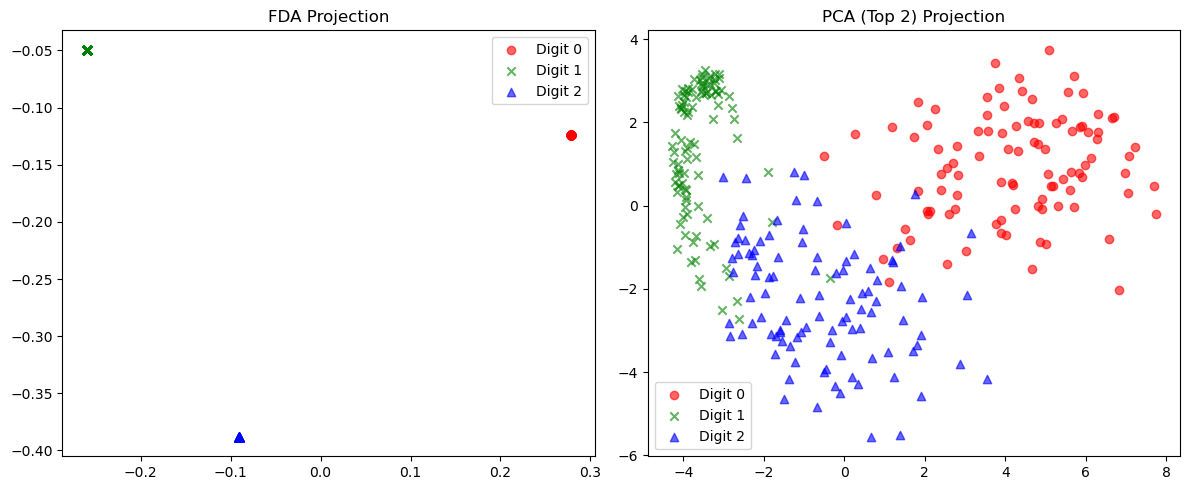

In [218]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
targets = [(X_train_fda, "FDA Projection"), (Y_train_2.T, "PCA (Top 2) Projection")]
colors, markers = ['r', 'g', 'b'], ['o', 'x', '^']

for ax, (data, title) in zip(axes, targets):
    for i, c in enumerate([0, 1, 2]):
        mask = (y_train == c)
        ax.scatter(data[mask, 0], data[mask, 1], c=colors[i], marker=markers[i], label=f"Digit {c}", alpha=0.6)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()